<a href="https://colab.research.google.com/github/RAPID-Facility/rAPIdtools/blob/main/examples/single_image_vlm_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install `rapidtools` Python Package**

In [1]:
!pip install git+https://github.com/RAPID-Facility/rAPIdtools

  Cloning https://github.com/RAPID-Facility/rAPIdtools to /tmp/pip-req-build-hwsxtr2i
  Running command git clone --filter=blob:none --quiet https://github.com/RAPID-Facility/rAPIdtools /tmp/pip-req-build-hwsxtr2i
  Resolved https://github.com/RAPID-Facility/rAPIdtools to commit 5f58e6e56fc480ededf8886010686434ac8d8619
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 59.0 MB/s eta 0:00:00
  Created wheel for rapidtools: filename=rapidtools-0.1.0-py3-none-any.whl size=200590 sha256=de685c95e4499114ba26c6b1d5d81e6eeb1e575c544e924018bd4dd80b1932bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-y9r4zfh8/wheels/a7/e2/29/6e405ee9b0156a0f0b38c4bd39dca5ddfe5d45fea5a9ba93a9
Successfully built

## **Load the Disaster Imagery**

2026-07-21 00:21:17- INFO: NumExpr defaulting to 2 threads.
2026-07-21 00:21:37- INFO: Preparing to download 1 file(s) across 1 dataset(s)...


2026-07-21 00:21:37- INFO: Successfully secured 1/1 files.
2026-07-21 00:21:37- INFO: HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"


2026-07-21 00:21:38- INFO: HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
2026-07-21 00:21:38- INFO: Hugging Face auto-authentication successful.
2026-07-21 00:21:38- INFO: Preparing to download 1 file(s) across 1 dataset(s)...


2026-07-21 00:21:38- INFO: Successfully secured 1/1 files.


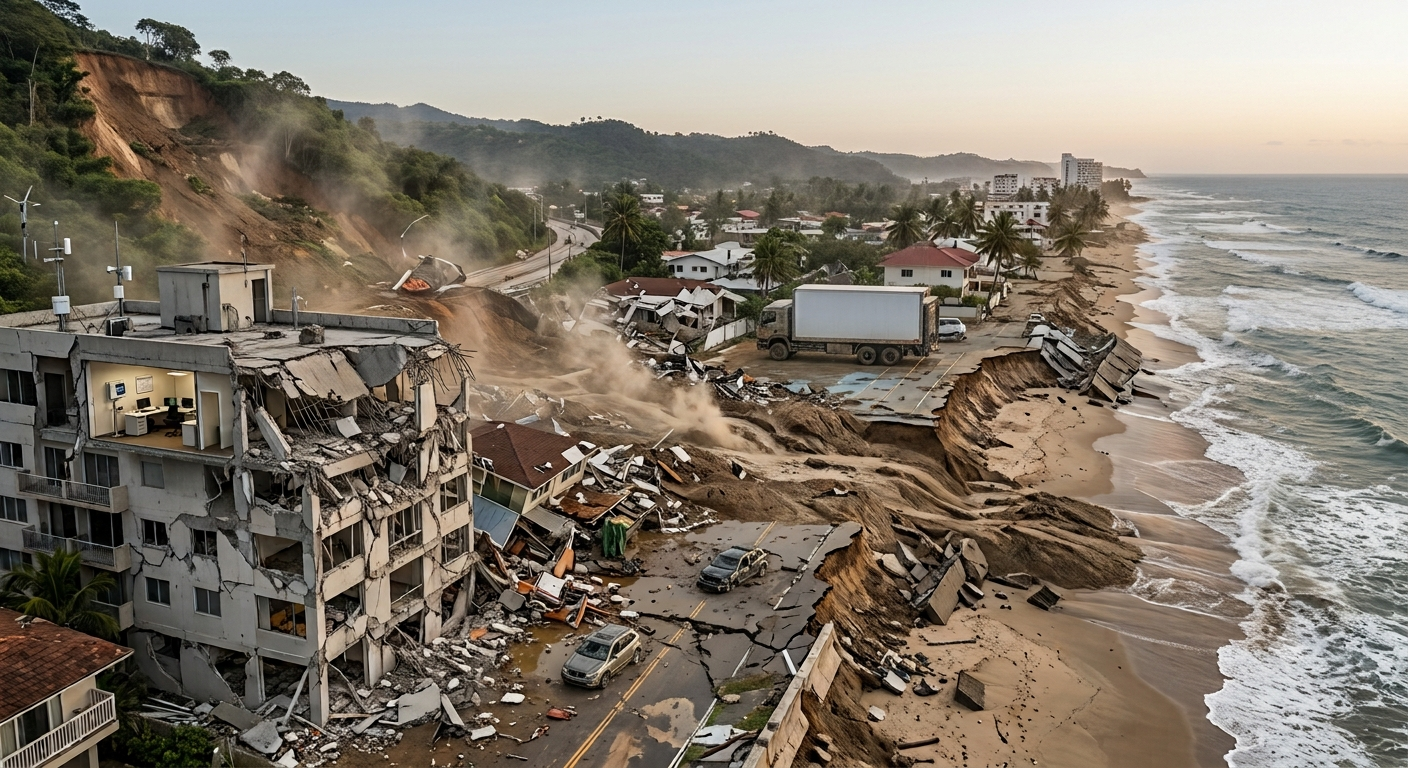

In [2]:
from rapidtools import Gemma4Inference, download_dataset
from PIL import Image
from IPython.display import display

# Download our generated disaster reconnaissance photo
[image_path] = download_dataset('synthetic_landslide_image')

display(Image.open(image_path))

## **Initialize the AI Model**

In [ ]:
# Initialize the local inference model for Google's Gemma-4 vision-language model.
vlm_model = Gemma4Inference(
    model_id='google/gemma-4-E2B-it',
    temperature=0.4
)

2026-07-21 00:21:38- INFO: Loading processor for google/gemma-4-E2B-it...


processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

2026-07-21 00:21:47- INFO: Loading model google/gemma-4-E2B-it (this may take a while)...


model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

## **Write Your Custom Query**

In [ ]:
# Define your prompt
PROMPT_STRING = "Describe the condition of this post-disaster scene and what went wrong."

## **Run the AI Inference and View Results**

In [ ]:
# Send the image and your custom prompt to the Vision-Language Model
# for analysis, then print the AI's diagnostic response to the screen.
output = vlm_model.run_inference(
        image_inputs=image_path,
        prompt=PROMPT_STRING
    )

print(output.text)